In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def create_tri_matrix(n):
    smaller = np.ones(n-1)
    diagonal = 4 * np.ones(n)
    return np.diag(smaller, -1) + np.diag(diagonal, 0) + np.diag(smaller, 1)

In [3]:
#xs = np.array
#ys = np.array
#edge_derivatives = list of two numbers
def find_derivatives(xs, ys, edge_derivatives = None):
    n = len(xs)-1
    tri_matrix = create_tri_matrix(n-1)
    h = (xs[-1] - xs[0])/n
    rhs = (ys[2:] - ys[:-2]) * (3/h)
    if edge_derivatives == None:
        edge_derivatives = [0, 0]
    known_derivatives = np.zeros(n-1)
    known_derivatives[0] = edge_derivatives[0]
    known_derivatives[-1] = edge_derivatives[-1]
    rhs = rhs - known_derivatives
    inner_derivatives = np.linalg.solve(tri_matrix, rhs)
    inner_derivatives = np.pad(inner_derivatives, (1,1), mode = 'constant', constant_values = 0)
    inner_derivatives[0] = edge_derivatives[0]
    inner_derivatives[-1] = edge_derivatives[-1]
    return inner_derivatives

In [4]:
class Polynom():
    def __init__(self, coeff):
        self.coeff = np.array(coeff)
    def evaluate(self, x):
        xs = np.power(x, np.arange(len(self.coeff)))
        return xs @ self.coeff

    def __call__(self, x):
        return self.evaluate(x)

    def __str__(self,):
        degree = len(self.coeff) - 1
        terms = []
        first_written = False
        for i, coef in enumerate(self.coeff):
            if coef == 0:
                continue

            term = f"{abs(coef)}"
            if i == 0:
                terms.append(term)
                first_written = True
                continue

            if coef != 1 and coef != -1:
                term += "x"
            else:
                term = "x"
            if i != 1:
                term += f"^{i}"
            if first_written:
                if coef < 0:
                    term = f" - {term}"
                else:
                    term = f" + {term}"
            else:
                first_written = True
                if coef < 0:
                    term = f" -{term}"
            terms.append(term)

        return "f(x) = " + "".join(terms)
    def __repr__(self,):
        return "Polynomial: " + self.__str__()

In [5]:
H0 = Polynom([1, 0, -3, 2])
H1 = Polynom([0, 0, 3, -2])
H2 = Polynom([0, 1, -2, 1])
H3 = Polynom([0, 0, -1, 1])

In [6]:
H0

Polynomial: f(x) = 1 - 3x^2 + 2x^3

In [7]:
class TransformFunction():
    def __init__(self, lower_bound, upper_bound):
        self.lower_bound = lower_bound
        self.upper_bound = upper_bound
        self.size = upper_bound - lower_bound
    def evaluate(self, x):
        return (x - self.lower_bound) / self.size

    def __call__(self, x):
        return self.evaluate(x)

In [8]:
class Spline():
    def __init__(self, val_start, val_end, der_start, der_end, transform_function):
        self.val_start = val_start
        self.val_end = val_end
        self.der_start = der_start
        self.der_end = der_end
        self.transform_function = transform_function

    def evaluate(self, x):
        t_x = self.transform_function(x)
        h = self.transform_function.size
        result = self.val_start * H0(t_x)
        result += self.val_end * H1(t_x)
        result += h * self.der_start * H2(t_x)
        result += h * self.der_end * H3(t_x)
        return result

    def __call__(self, x):
        return self.evaluate(x)


In [9]:
class HermiteFunction():
    def __init__(self, splines, xs):
        self.splines = splines
        self.xs = xs
    def evaluate(self, x):
        spline_to_use = np.searchsorted(self.xs, x) - 1
        if spline_to_use is None or spline_to_use < 0:
            spline_to_use = 0
        if spline_to_use >= len(self.splines):
            spline_to_use = len(self.splines) - 1
        return self.splines[spline_to_use](x)

    def __call__(self, x):
        return self.evaluate(x)

In [10]:
def create_hermite_function(xs, ys, derivatives):
    splines = []
    for i in range(len(xs)-1):
        transform_function = TransformFunction(xs[i], xs[i+1])
        spline = Spline(ys[i], ys[i+1], derivatives[i], derivatives[i+1], transform_function)
        splines.append(spline)
    return HermiteFunction(splines, xs)

In [11]:
xs = np.array([1, 2, 3, 4, 5, 6])
ys = np.array([1, -2, 4, -8, 16, -32])

In [12]:
derivatives = find_derivatives(xs, ys, edge_derivatives = [0, 0])

In [13]:
interpolation_func = create_hermite_function(xs, ys, derivatives)

In [14]:
ts = np.arange(xs[0], xs[-1], 0.02)

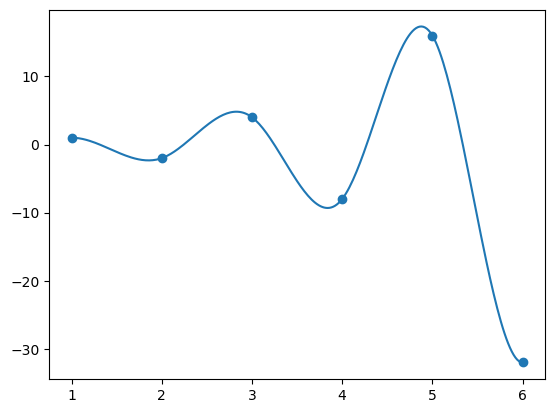

In [15]:
plt.plot(ts, (np.vectorize(interpolation_func)(ts)))
plt.scatter(xs, ys)